In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('../../../data/processed/wearables_by_period/df_15_primeros_EB2_prog.csv')#, index_col=0)

## Handle any abnormal HR or sleep duration values

In [3]:
df.loc[df.heart_rate_hr_mean<0,'heart_rate_hr_mean']=np.nan
df.loc[df.heart_rate_hr_baseline<0,'heart_rate_hr_baseline']=np.nan
df.loc[df.heart_rate_hr_min<0,'heart_rate_hr_min']=np.nan
df.loc[df.heart_rate_hr_max<0,'heart_rate_hr_max']=np.nan

In [4]:
# If sleep > 24h, replace with NaN
df.loc[df.sleep_duration>(60*60*24),'sleep_duration']=np.nan

# Stacked violin plots

In [5]:
df.loc[df.Respuesta=='no-E.PD','Respuesta']='non-E.PD controls'

df['Respuesta'] = pd.Categorical(df['Respuesta'],
                                   categories=['E.PD', 'non-E.PD controls'],
                                   ordered=True)
df = df.sort_values('Respuesta')

In [6]:
table_vars=[ 'steps_steps_total','activity_walking','location_distance',
             'location_clusters_count','sleep_duration','app_usage_total',
             'location_time_home','practiced_sport','heart_rate_hr_mean',
             'heart_rate_hr_min','heart_rate_sleep_mean','heart_rate_sleep_min',
             'oxygen_saturation_mean_spo2','oxygen_saturation_max_spo2',
             'emotions_valence_pred','total_unlocks','total_communication',
             'total_social_networks','total_others','sleep_start','deep_time',
             'light_time','rem_time']

In [7]:
vars_w_change=['sleep_duration','heart_rate_hr_mean','heart_rate_hr_min','heart_rate_sleep_mean',
               'heart_rate_sleep_min','oxygen_saturation_mean_spo2','emotions_valence_pred','total_social_networks','total_others',
              ]

In [8]:
df_melted = df.melt(id_vars=[ 'ID', 'Respuesta'], value_vars=table_vars, 
                     var_name='variable', value_name='value')

In [9]:
df_melted_medians=df_melted.groupby(['ID','Respuesta','variable']).median().reset_index()

/var/folders/nm/zjh2_fld07sfnhxsrc8fykv0ply609/T/ipykernel_2769/3288386209.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_melted_medians=df_melted.groupby(['ID','Respuesta','variable']).median().reset_index()


In [10]:
df_normalized = df_melted_medians.copy()
for var in table_vars:
    mean_val= df_melted_medians.loc[ ((df_melted_medians['variable']==var)&(df_melted_medians['Respuesta']=='E.PD')), 'value'].mean()
    median_val= df_melted_medians.loc[ ((df_melted_medians['variable']==var)&(df_melted_medians['Respuesta']=='E.PD')), 'value'].median()
    
    min_val = df_melted_medians.loc[df_melted_medians['variable']==var,'value'].min()
    max_val = df_melted_medians.loc[df_melted_medians['variable']==var,'value'].max()
    df_normalized.loc[df_melted_medians['variable']==var,'value'] = (df_melted_medians.loc[df_melted_medians['variable']==var,'value'] / mean_val)*100


In [11]:
variable_names = {
    'steps_steps_total': 'Total Steps',
    'activity_walking': 'Activity walking',
    'location_distance': 'Location distance',
    'location_clusters_count': 'Location clusters',
    'sleep_duration': 'Sleep duration',
    'app_usage_total': 'Phone use total time',
    'location_time_home': 'Time at home',
    'practiced_sport': 'Practiced sport (self-reported)',
    'heart_rate_hr_mean': 'Average heart rate (24 hours)',
    'heart_rate_hr_min': 'Minimum heart rate',
    'heart_rate_sleep_mean': 'Average heart rate (sleeping time)',
    'heart_rate_sleep_min': 'Minimum heart rate (sleeping time)',
    'oxygen_saturation_mean_spo2': 'Peripheral oxygen saturation',
    'oxygen_saturation_max_spo2': 'Peripheral oxygen saturation',
    'emotions_valence_pred': 'Emotions valence',
    'total_unlocks': 'Total phone unlocks',
    'total_communication': 'Phone use: Communication',
    'total_social_networks': 'Phone use: Social Networks',
    'total_others': 'Phone use: others',
    'sleep_start': 'Sleep start time',
    'deep_time': 'Sleep time: deep',
    'light_time': 'Sleep time: light',
    'rem_time': 'Sleep time: REM'
}

/var/folders/nm/zjh2_fld07sfnhxsrc8fykv0ply609/T/ipykernel_2769/3323071865.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.05, 0.01, 0.99, 0.98])


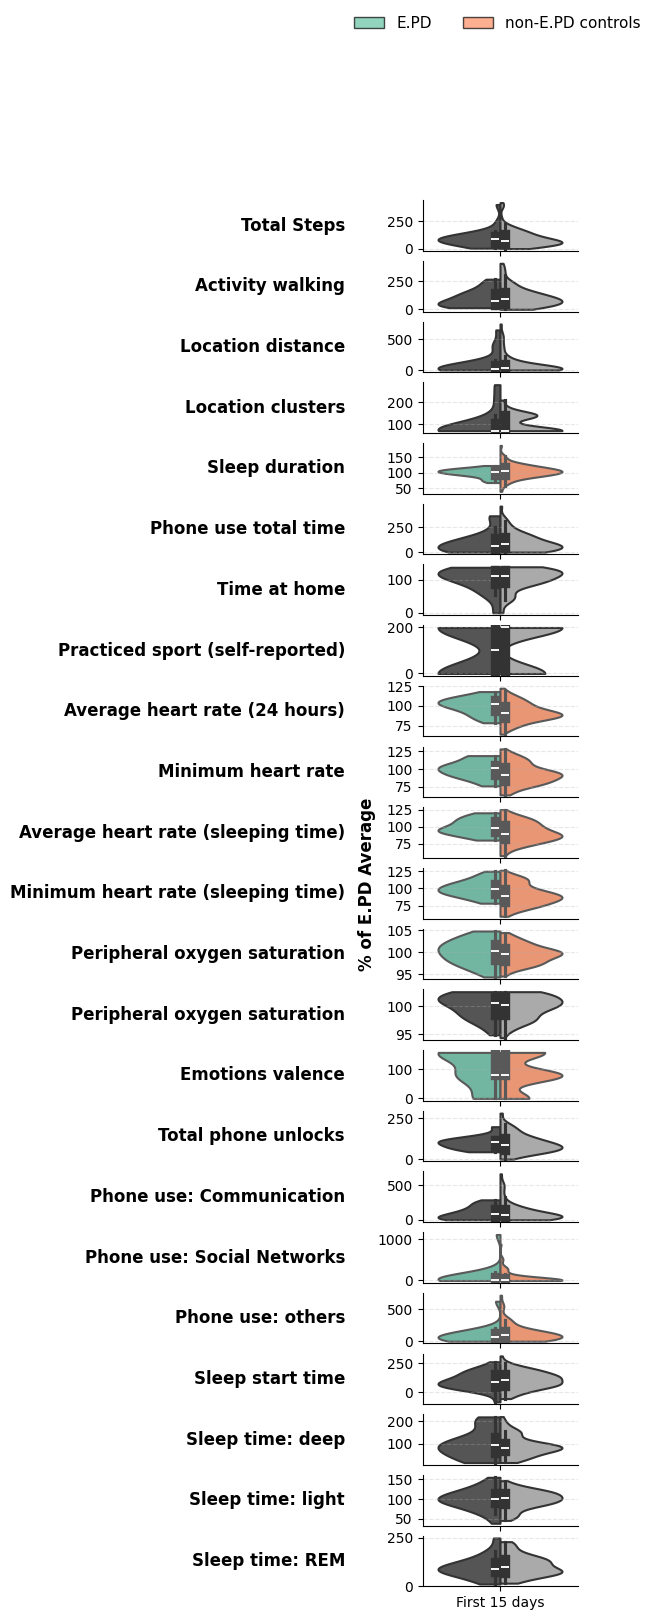

In [12]:
groups_list = df['Respuesta'].unique()
colors = sns.color_palette('Set2', n_colors=len(groups_list))

# Create stacked violin plot with variables on rows
# Increase width from 2 to at least 6-8 inches
fig, axes = plt.subplots(len(table_vars[0:]), 1, figsize=(2, 18), 
                         sharex=True, sharey=False)

# Get unique groups for x-axis positions
groups = df['Respuesta'].unique()
colors = sns.color_palette('Set2', n_colors=len(groups))

for i, var in enumerate(table_vars[0:]):
    data = df_normalized[df_normalized['variable'] == var].copy()
    data['dummy'] = 'First 15 days'

    if var in vars_w_change:
        # Use seaborn's split violin plot
        sns.violinplot(data=data, x=np.zeros(len(data)), y='value', hue='Respuesta',
                       split=True, inner='box', palette=colors, ax=axes[i],
                       linewidth=1.5, cut=0, hue_order=['E.PD', 'non-E.PD controls'])
    else:
        # Use seaborn's split violin plot
        sns.violinplot(data=data, x=np.zeros(len(data)), y='value', hue='Respuesta',
                       split=True, inner='box', palette='gray', ax=axes[i],
                       linewidth=1.5, cut=0, hue_order=['E.PD', 'non-E.PD controls'], color='gray')
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticks([0], ['First 15 days'])
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].legend().remove()
    
    # Add variable name on the left
    axes[i].text(-0.5, 0.5, variable_names[var], transform=axes[i].transAxes,
                 fontsize=12, fontweight='bold', va='center', ha='right')

# Add legend at the top
handles = [plt.Rectangle((0,0),1,1, facecolor=colors[j], edgecolor='black', alpha=0.7) 
           for j in range(len(groups_list))]
fig.legend(handles, groups_list, loc='upper center', ncol=2, 
          frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.99))

# Add y-axis label
fig.text(-0.2, 0.5, '% of E.PD Average', va='center', 
         rotation='vertical', fontsize=12, fontweight='bold')

# Use ONLY tight_layout with adjusted rect to leave space for labels
plt.tight_layout(rect=[0.05, 0.01, 0.99, 0.98])

#plt.savefig('violins_first15.svg', bbox_inches='tight')
plt.show()

# Histograms

Text(0.5, 0, 'Median steps per day (first 15 days)')

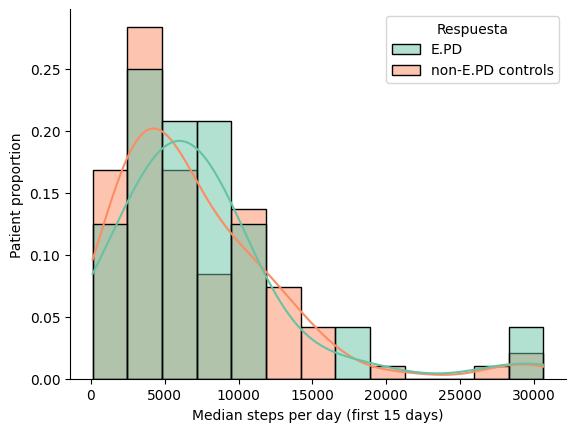

In [13]:
sns.histplot(df_melted_medians[df_melted_medians['variable'] == 'steps_steps_total'],x='value', hue='Respuesta',kde=True, 
             palette=colors,stat='proportion', common_norm=False, hue_order=['E.PD', 'non-E.PD controls'])
sns.despine()
plt.ylabel('Patient proportion')
plt.xlabel('Median steps per day (first 15 days)')
#plt.savefig('hist_steps_first15.svg')

Text(0.5, 0, 'Median of daily average HR (bpm, First 15 days)')

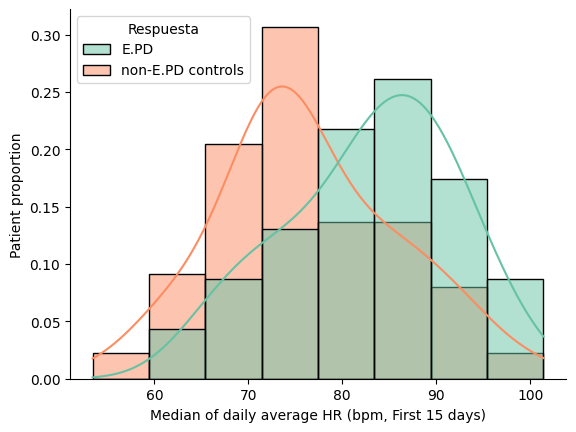

In [14]:
sns.histplot(df_melted_medians[df_melted_medians['variable'] == 'heart_rate_hr_mean'],x='value', hue='Respuesta',kde=True, 
             palette=colors,stat='proportion', common_norm=False, hue_order=['E.PD', 'non-E.PD controls'])
sns.despine()
plt.ylabel('Patient proportion')
plt.xlabel('Median of daily average HR (bpm, First 15 days)')
#plt.savefig('hist_HR_first15.svg')